In [42]:
import jax
import jax.numpy as jnp
from typing import Optional, Literal
from flax import linen as nn
import networkx as nx
import jax.extend.core as core
import matplotlib.pyplot as plt

from metanca.nn import forward_factory, flatten_params
from metanca.neighbors import build_compute_graph, build_parameter_neighbor_graphs, PARAMETER_OP_NAME, INPUT_OP_NAME

In [43]:
class TinyMLP(nn.Module):
    hidden_dim: int = 8
    out_dim: int = 2

    @nn.compact
    def __call__(self, x: jax.Array) -> jax.Array:
        dense1 = nn.Dense(self.hidden_dim)
        dense2 = nn.Dense(self.out_dim)
        h = dense1(x)
        act = nn.relu(h)
        return dense2(act)

class ResidualMLP(nn.Module):
    n_layers: int = 2
    hidden_dim: int = 8
    out_dim: int = 2

    @nn.compact
    def __call__(self, x):
        
        residual = TinyMLP(self.hidden_dim, self.hidden_dim)(x)        
        for i in range(self.n_layers - 1):
            y = TinyMLP(self.hidden_dim, self.hidden_dim)(residual)
            residual = residual + y
                
        # Assume x.shape[-1] == out_dim
        return residual

In [44]:
key = jax.random.key(0)
x = jnp.ones((1, 4))
model = ResidualMLP(n_layers=3)
params = model.init(key, x)
forward = forward_factory(model, params)
jaxpr = jax.make_jaxpr(forward)(x).jaxpr

In [45]:
vars_and_params = [(var, param, name) for var, (name, param) in zip(jaxpr.constvars, flatten_params(params["params"]))]
var2name = {var: name for var, _, name in vars_and_params}

In [46]:
compute_graph = build_compute_graph(jaxpr)
fwd, bwd = build_parameter_neighbor_graphs(compute_graph)

In [47]:
def map_layers_to_ops(compute_graph: nx.DiGraph) -> dict[int, list["OpNode"]]:  # noqa: F821
    node2layer_id = {node: node.eqn_id + 1 for node in compute_graph if node.eqn_id is not None}
    for parameter_op in filter(lambda u: u.primitive.name == PARAMETER_OP_NAME, compute_graph):
        next_op = list(compute_graph.successors(parameter_op))[0]
        node2layer_id[parameter_op] = next_op.eqn_id + 1
    
    input_op = next(filter(lambda u: u.primitive.name == INPUT_OP_NAME, compute_graph))
    node2layer_id[input_op] = 0
    
    layer2node = {layer_id: [] for layer_id in set(node2layer_id.values())}
    
    for node, layer_id in node2layer_id.items():
        layer2node[layer_id].append(node)
        
    return layer2node

def map_ops_to_names(compute_graph: nx.DiGraph, var2name: dict[core.Var, str]) -> dict["OpNode", str]:  # noqa: F821
    label_names = {op: op.primitive.name for op in compute_graph}
    for op, label in label_names.items():
        if label == "custom_jvp_call":
            label_names[op] = op.primitive.params["call_jaxpr"].eqns[0].params["name"]
        elif label == PARAMETER_OP_NAME:
            label_names[op] = var2name[op.outvars[0]]

    return label_names

def plot_neighbors(
    query_name: str,
    compute_graph: nx.DiGraph,
    var2name: dict[core.Var, str],
    ax: plt.Axes,
    forward_neighbor_graph: Optional[nx.DiGraph] = None,
    backward_neighbor_graph: Optional[nx.DiGraph] = None,
    scale: Optional[int] = None,
    align: Literal["horizontal", "vertical"] = "vertical",
    node_size: int = 15,
    query_node_color: str = "C0",
    neighbor_node_color: str = "C1",
    other_node_color: str = "gray",
):

    name2var = {v: k for k, v in var2name.items()}

    # badly specified param name
    if query_name not in name2var:
        raise ValueError(f"{query_name} is not a parameter name.")

    # choose neighbor graph ... can't pass in both or neither.
    
    if (
        backward_neighbor_graph is None and forward_neighbor_graph is None
    ) or (
        backward_neighbor_graph is not None and forward_neighbor_graph is not None
    ):
        raise TypeError("One of `backward_neighbor_graph` or `forward_neighbor_graph` should be provided")
    elif forward_neighbor_graph is not None:
        neighbor_graph = forward_neighbor_graph
        neighbor_type = "forward"
    else:
        neighbor_graph = backward_neighbor_graph
        neighbor_type = "backward"

    # get the jaxpr Var associated with this param name.
    var = name2var[query_name]
    # map this Var to the right OpNode in the compute graph.
    query_op = next(filter(lambda u: u.primitive.name == PARAMETER_OP_NAME and u.outvars[0] == var, compute_graph))

    # get the jaxpr Vars representing the forward/backward neighbors. 
    neighbor_vars = set(neighbor_graph.predecessors(var))
    # map these vars to the right OpNodes in the compute graph.
    neighbor_ops = list(filter(lambda u: u.primitive.name == PARAMETER_OP_NAME and u.outvars[0] in neighbor_vars, compute_graph))

    # partition out the non neighbors.
    non_neighbor_ops = [op for op in compute_graph if op not in set(neighbor_ops) | {query_op}]

    # get layer assignments
    layer2node = map_layers_to_ops(compute_graph)

    # get display names of each op.
    op2name = map_ops_to_names(compute_graph, var2name)

    # build positions
    pos = nx.multipartite_layout(compute_graph, subset_key=layer2node, scale=scale, align=align)

    # draw query node
    nx.draw_networkx_nodes(
        compute_graph,
        pos=pos,
        nodelist=[query_op],
        node_color=query_node_color,
        label="query",
        node_size=node_size,
        ax=ax
    )

    # draw neighbor nodes
    nx.draw_networkx_nodes(
        compute_graph,
        pos=pos,
        nodelist=neighbor_ops,
        node_color=neighbor_node_color,
        label=f"{neighbor_type} neighbors",
        node_size=node_size,
        ax=ax
    )

    # draw the rest of the nodes
    nx.draw_networkx_nodes(
        compute_graph,
        pos=pos,
        nodelist=non_neighbor_ops,
        node_color=other_node_color,
        alpha=0.3,
        label="other nodes",
        node_size=node_size,
        ax=ax
    )

    # draw the compute graph edges
    nx.draw_networkx_edges(
        compute_graph, pos=pos,
        connectionstyle="arc3,rad=0.1",  # <-- THIS IS IT
        ax=ax
    )

    # write out the label text
    text = nx.draw_networkx_labels(
        compute_graph,
        pos=pos,
        labels=op2name,
        font_size=10,
        clip_on=False,
        ax=ax
    )

    # rotate text 45 degrees.
    for _, t in text.items():
        t.set_rotation(90)

    # place the title as the ylabel
    ax.set_ylabel(f"{neighbor_type.capitalize()} neighbors of {query_name}")

In [48]:
print("Parameters to query:")
print("====================")
print(*var2name.values(), sep="\n")

Parameters to query:
TinyMLP_0.Dense_0.kernel
TinyMLP_0.Dense_0.bias
TinyMLP_0.Dense_1.kernel
TinyMLP_0.Dense_1.bias
TinyMLP_1.Dense_0.kernel
TinyMLP_1.Dense_0.bias
TinyMLP_1.Dense_1.kernel
TinyMLP_1.Dense_1.bias
TinyMLP_2.Dense_0.kernel
TinyMLP_2.Dense_0.bias
TinyMLP_2.Dense_1.kernel
TinyMLP_2.Dense_1.bias


In [49]:
query_param = "TinyMLP_1.Dense_0.kernel"

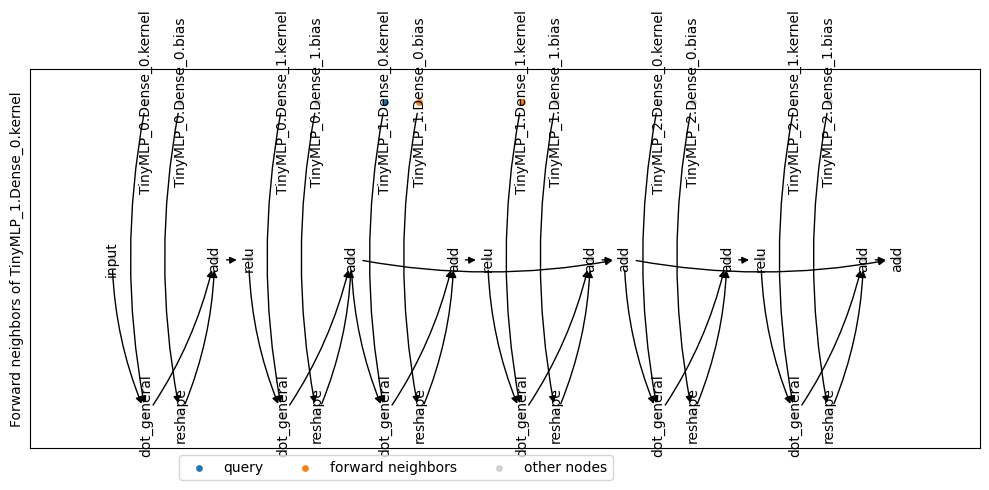

In [50]:
fig, ax = plt.subplots(1, figsize=(10, 5))
plot_neighbors(query_param, compute_graph, var2name, ax, scale=1, forward_neighbor_graph=fwd, align="vertical")
plt.legend(bbox_to_anchor=(0.15, 0), ncols=3)
plt.tight_layout()
plt.savefig("forward_neighbors.pdf", bbox_inches="tight")
plt.show()

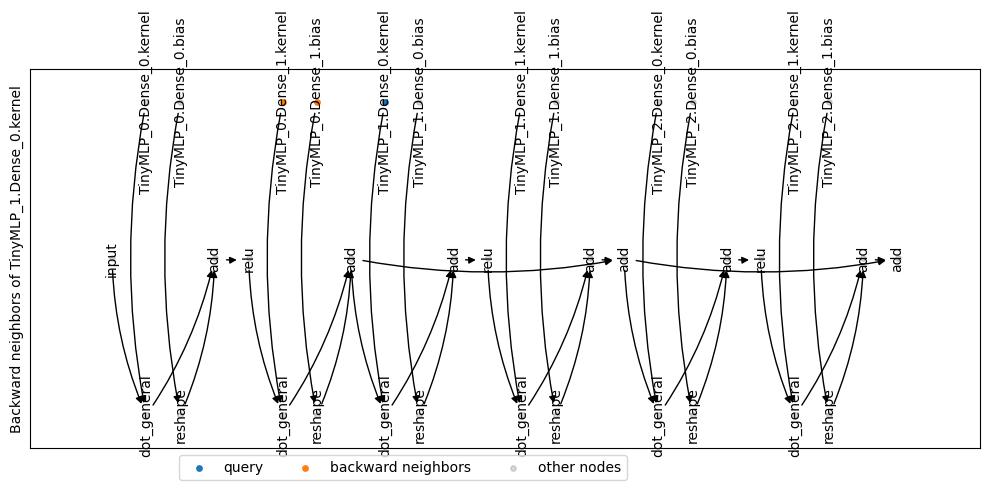

In [51]:
fig, ax = plt.subplots(1, figsize=(10, 5))
plot_neighbors(query_param, compute_graph, var2name, ax, scale=1, backward_neighbor_graph=bwd)
plt.legend(bbox_to_anchor=(0.15, 0), ncols=3)
plt.tight_layout()
plt.savefig("backward_neighbors.pdf", bbox_inches="tight")
plt.show()

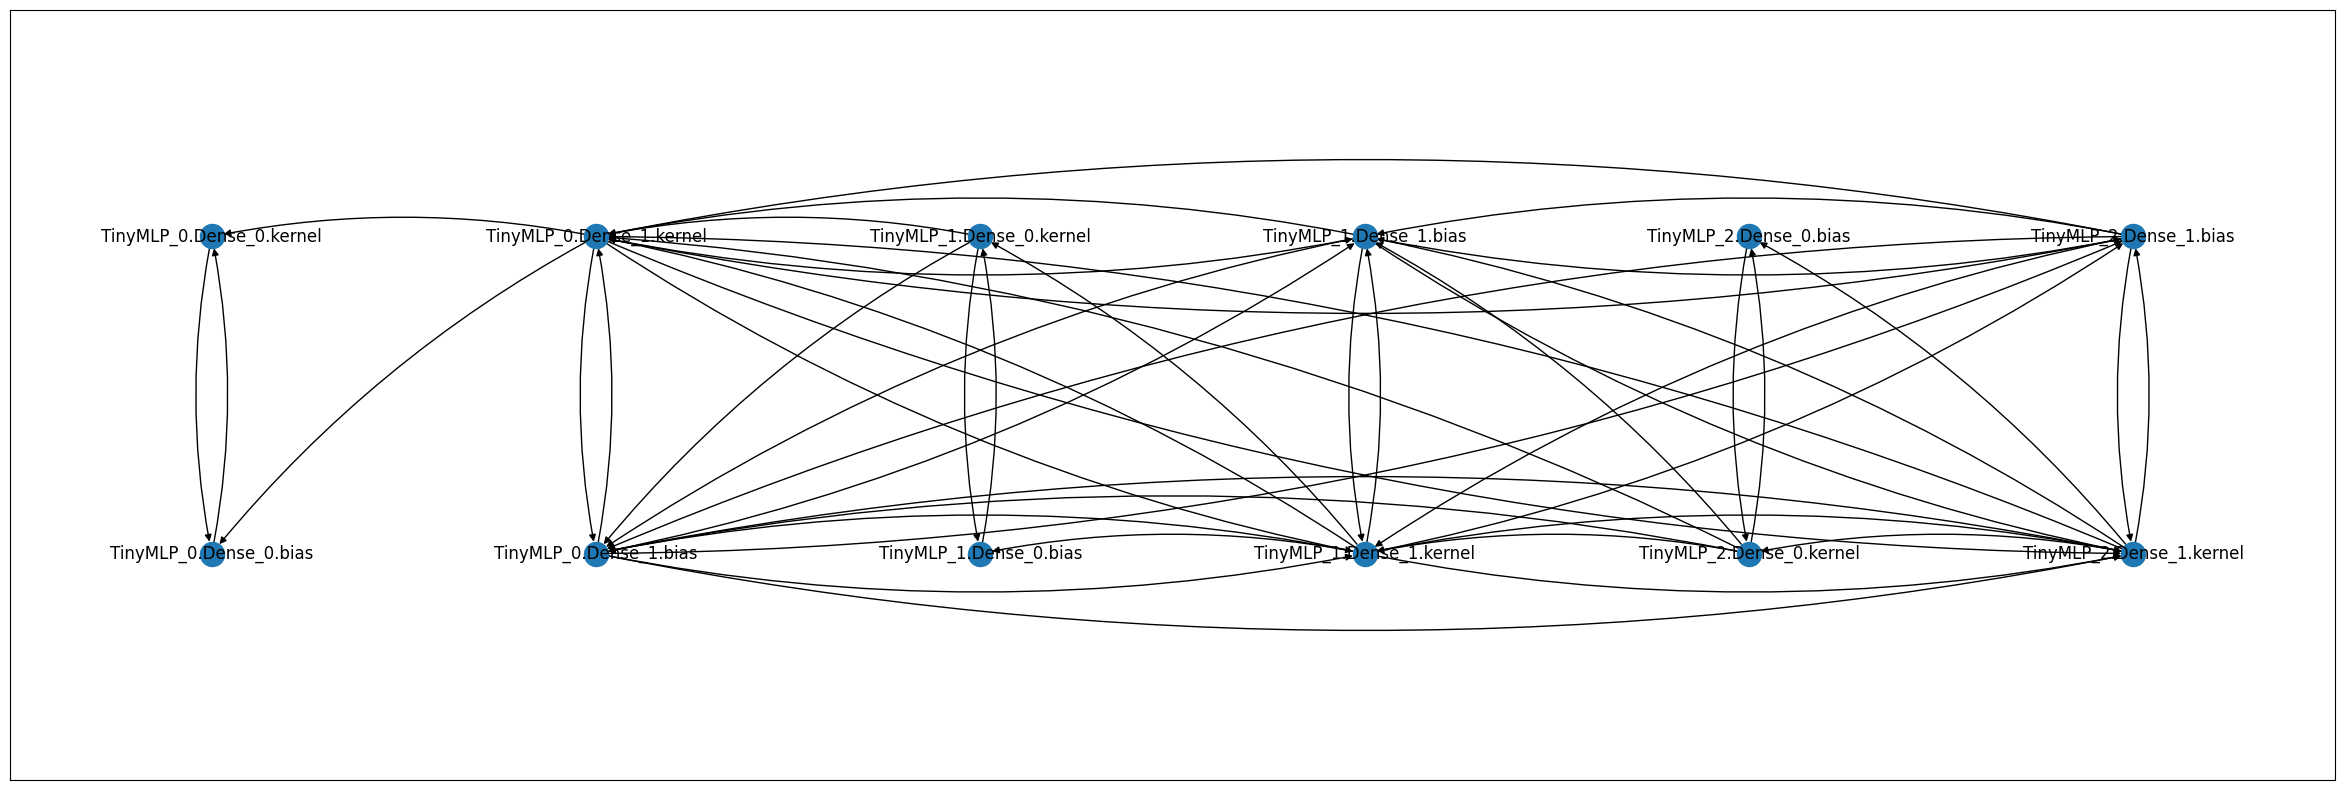

In [11]:
#pos = nx.bfs_layout(fwd.to_undirected(), start=name2var["TinyMLP_0.Dense_0.kernel"])
fig, ax = plt.subplots(1, figsize=(30, 10))
nx.set_node_attributes(fwd, values={var: ".".join(var2name[var].split(".")[:-1]) for var in fwd}, name="layer")
pos = nx.multipartite_layout(fwd, subset_key="layer")
#nx.draw_networkx(fwd, pos=pos, with_labels=True, labels=var2name, ax=ax)
nx.draw_networkx_nodes(fwd, pos)# labels=var2name, ax=ax)
nx.draw_networkx_edges(
    fwd, pos=pos,
    connectionstyle="arc3,rad=0.1",  # <-- THIS IS IT
    ax=ax
)
nx.draw_networkx_labels(fwd, pos=pos, labels=var2name)
plt.show()
#plt.savefig("/Users/dberenberg/Desktop/fwd_neighbors.pdf", bbox_inches="tight")